# BCI for Inner Speech Decoding: Setup and Data Exploration

## Imports

In [1]:
# Import required libraries
import mne
import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
import sys
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from mne.decoding import CSP


## Set paths

In [38]:
# Add the Inner Speech Dataset repository to the system path
project_root = Path.cwd()
print(f"Current working directory: {project_root}")
if not (project_root / "Python_Processing").exists():
    project_root = project_root / "Inner_Speech_Dataset-main"
sys.path.insert(0, str(project_root / "Python_Processing"))
print(f"Python_Processing directory added to system path: {sys.path[0]}")

# Reload custom modules so notebook picks up edits without a kernel restart
import importlib
import lib.data_extractions as data_extractions
import utils as utils_module
importlib.reload(data_extractions)
importlib.reload(utils_module)

# Import custom functions from the Inner Speech Dataset repository
from lib.data_extractions import (
    extract_data_from_subject,
    extract_data_multisubject,
)
from lib.data_processing import (
    select_time_window,
    transform_for_classificator,
)

from lib.download_helper import (
    _clone_inner_speech,
    get_derivatives,
)


# Set random seed for reproducibility
np.random.seed(23)

# Configure MNE to show only warnings (suppress info messages)
mne.set_log_level(verbose="warning")

# Suppress deprecation and future warnings
warnings.filterwarnings(action="ignore", category=DeprecationWarning)
warnings.filterwarnings(action="ignore", category=FutureWarning)

print("Setup complete! All libraries imported successfully.")

Current working directory: d:\Documents\code\comp neuro\ds003626
Python_Processing directory added to system path: d:\Documents\code\comp neuro\ds003626\Inner_Speech_Dataset-main\Python_Processing
Setup complete! All libraries imported successfully.


## Clone Dataset

In [ ]:

# Using this path to download the dataset
data_dir = Path().resolve().parent

# Clone just the structure (no files yet). This step is needed to create the
data_dir = _clone_inner_speech(target_dir=data_dir, verbose=False)

# Download the files needed for this script. This can take some minutes.
get_derivatives(
    dataset_path=data_dir,
    subjects="all",
    sessions="all",
    file_types=["eeg","events"],
    verbose=True,
    progress=True,
)


## Parameters

In [3]:
# Original sampling rate
sfreq = 256

# Target sampling rate
target_sfreq = 128

# Filtering parameters
lowcut = 1.0
highcut = 40.0

notch_freq = 50.0  # use 60 if your environment uses 60Hz mains

# Epoch window
tmin = 0.0
tmax = 2.0

In [19]:
# Set the hyperparameters for data loading and processing

# Directory containing the dataset (adjust this to your local path)
root_dir = Path.cwd().parent / "ds003626" # Path to the dataset

# Specify which type of data to use
# Options: "EEG" (brain activity), "exg" (physiological signals), or "baseline" (resting state)
datatype = "EEG"

# EEG sampling rate (256 samples per second)
fs = 256

# Select the time window of interest (in seconds)
# The cue appears at t=0, action period is between 1.5s and 3.5s
t_start = 1.5  # Start time after cue
t_end = 3.5  # End time after cue

# All subjects to analyze (1-10)
n_s_list = list(range(1, 11))

print(
    f"Parameters set: Using {datatype} data from subjects {n_s_list}, analyzing time window {t_start}s to {t_end}s"
)

Parameters set: Using EEG data from subjects [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], analyzing time window 1.5s to 3.5s


## Explore the data from subject 1

In [27]:
import gc

# Clear large arrays from earlier notebook runs so the new full-dataset load has memory to work with
for var_name in [
    "X",
    "Y",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "X_train_alpha",
    "X_test_alpha",
    "X_train_beta",
    "X_test_beta",
    "X_train_a",
    "X_test_a",
    "X_train_b",
    "X_test_b",
    "X_train_final",
    "X_test_final",
]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()

# Load all trials one subject at a time to keep memory usage manageable
# Each subject is windowed and filtered before being added to the full dataset
Conditions = [["Inner"], ["Inner"], ["Inner"], ["Inner"]]
Classes = [["Up"], ["Down"], ["Right"], ["Left"]]

subject_data = []
subject_labels = []

for subject in n_s_list:
    print(f"\nProcessing subject {subject}")
    X_sub, Y_sub = extract_data_from_subject(root_dir, subject, datatype)
    X_sub = select_time_window(X=X_sub, t_start=t_start, t_end=t_end, fs=fs)
    X_sub, Y_sub = transform_for_classificator(X_sub, Y_sub, Classes, Conditions)
    subject_data.append(X_sub.astype(np.float32, copy=False))
    subject_labels.append(Y_sub.astype(np.int64, copy=False))
    del X_sub, Y_sub
    gc.collect()

X = np.concatenate(subject_data, axis=0)
Y = np.concatenate(subject_labels, axis=0)

del subject_data, subject_labels
gc.collect()

print("Data successfully loaded!")
print("\nX (EEG data) shape:", X.shape)
print("  - Number of trials:", X.shape[0])
print("  - Number of EEG channels:", X.shape[1])
print("  - Number of time points per trial:", X.shape[2])
print("  - Total duration per trial:", X.shape[2] / fs, "seconds")

print("\nY (labels) shape:", Y.shape)
print("  - Number of trials:", Y.shape[0])

# Check how many trials we have of each direction
class_labels = ["Up", "Down", "Right", "Left"]
print("\nNumber of trials per direction:")
for i, class_label in enumerate(class_labels):
    class_count = np.sum(Y == i)
    print(f"{class_label}: {class_count}")


Processing subject 1

Processing subject 2

Processing subject 3

Processing subject 4

Processing subject 5

Processing subject 6

Processing subject 7

Processing subject 8

Processing subject 9


d:\Documents\code\comp neuro\ds003626\Inner_Speech_Dataset-main\Python_Processing\lib\data_extractions.py:81: RuntimeWarning: Invalid tag with only 0/16 bytes at position 236151778
  X = mne.read_epochs(file_name, verbose="WARNING")
d:\Documents\code\comp neuro\ds003626\Inner_Speech_Dataset-main\Python_Processing\lib\data_extractions.py:84: RuntimeWarning: Skipping unreadable file for subject sub-09, session 1: d:\Documents\code\comp neuro\ds003626/derivatives/sub-09/ses-01/sub-09_ses-01_eeg-epo.fif (can only convert an array of size 1 to a Python scalar)
  warnings.warn(



Processing subject 10


d:\Documents\code\comp neuro\ds003626\Inner_Speech_Dataset-main\Python_Processing\lib\data_extractions.py:81: RuntimeWarning: Invalid tag with only 0/16 bytes at position 236151778
  X = mne.read_epochs(file_name, verbose="WARNING")
d:\Documents\code\comp neuro\ds003626\Inner_Speech_Dataset-main\Python_Processing\lib\data_extractions.py:84: RuntimeWarning: Skipping unreadable file for subject sub-10, session 3: d:\Documents\code\comp neuro\ds003626/derivatives/sub-10/ses-03/sub-10_ses-03_eeg-epo.fif (can only convert an array of size 1 to a Python scalar)
  warnings.warn(


Data successfully loaded!

X (EEG data) shape: (2076, 128, 512)
  - Number of trials: 2076
  - Number of EEG channels: 128
  - Number of time points per trial: 512
  - Total duration per trial: 2.0 seconds

Y (labels) shape: (2076,)
  - Number of trials: 2076

Number of trials per direction:
Up: 519
Down: 519
Right: 519
Left: 519


## Preprocessing and Feature Extraction

In [34]:
import sys
sys.path.append(".")

from utils import (
    resample_data,
    bandpass,
    remove_artifacts,
    baseline_correction,
    apply_notch_filter,
    apply_bandpass,
)

## Preprocessing

In [28]:
# Time window selection was already applied while loading each subject.
print("Time window selection complete!")
print("\nCurrent X (EEG data) shape:", X.shape)
print("  - Number of trials:", X.shape[0])
print("  - Number of EEG channels:", X.shape[1])
print("  - Number of time points per trial:", X.shape[2])
print("  - Selected duration per trial:", X.shape[2] / fs, "seconds")

# Calculate how many data points are currently loaded
total_data_points = X.shape[0] * X.shape[1] * X.shape[2]
print(f"\nTotal data points in selected window: {total_data_points:,}")

Time window selection complete!

Current X (EEG data) shape: (2076, 128, 512)
  - Number of trials: 2076
  - Number of EEG channels: 128
  - Number of time points per trial: 512
  - Selected duration per trial: 2.0 seconds

Total data points in selected window: 136,052,736


In [29]:
print("Data was already filtered to the 4 Inner Speech classes during loading.")
print("\nY now contains class labels:")
for idx, class_name in enumerate(["Up", "Down", "Right", "Left"]):
    print(f"- {idx} represents: {class_name}")

# Check how many trials we have for each class
n_up = np.sum(Y == 0)
n_down = np.sum(Y == 1)
n_right = np.sum(Y == 2)
n_left = np.sum(Y == 3)

print(f"\nNumber of 'Up' trials: {n_up}")
print(f"Number of 'Down' trials: {n_down}")
print(f"Number of 'Right' trials: {n_right}")
print(f"Number of 'Left' trials: {n_left}")

Data was already filtered to the 4 Inner Speech classes during loading.

Y now contains class labels:
- 0 represents: Up
- 1 represents: Down
- 2 represents: Right
- 3 represents: Left

Number of 'Up' trials: 519
Number of 'Down' trials: 519
Number of 'Right' trials: 519
Number of 'Left' trials: 519


In [30]:
selected_channels = np.arange(128)

X = X[:, selected_channels, :]

### CSP

In [31]:
csp = CSP(
    n_components=8,
    reg='ledoit_wolf',
    log=True,
    norm_trace=False
)

## Apply preprocessing pipeline

In [35]:
# Step 1: Resample
X = resample_data(X, sfreq, target_sfreq)

# Step 2: Bandpass filter
X = apply_bandpass(X, lowcut, highcut, target_sfreq)

# Step 3: Notch filter
X = apply_notch_filter(X, notch_freq, target_sfreq)

# Step 4: Baseline correction
# X = baseline_correction(X)

# Step 5: Artifact removal
# X, kept_indices = remove_artifacts(X)

# Y = Y[kept_indices]

print("Preprocessing complete.")
print("Processed X shape:", X.shape)

Preprocessing complete.
Processed X shape: (2076, 128, 256)


## Test Train Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state= 23,
    stratify=Y
)

## Apply CSP 
Ensure there are no data leaks

In [37]:
X_train_alpha = bandpass(X_train, 8, 12, fs=128)
X_test_alpha  = bandpass(X_test, 8, 12, fs=128)

X_train_beta = bandpass(X_train, 13, 30, fs=128)
X_test_beta  = bandpass(X_test, 13, 30, fs=128)

csp_alpha = CSP(n_components=4, log=True)
csp_beta  = CSP(n_components=4, log=True)

X_train_a = csp_alpha.fit_transform(X_train_alpha, y_train)
X_test_a  = csp_alpha.transform(X_test_alpha)

X_train_b = csp_beta.fit_transform(X_train_beta, y_train)
X_test_b  = csp_beta.transform(X_test_beta)

X_train_final = np.hstack([X_train_a, X_train_b])
X_test_final  = np.hstack([X_test_a, X_test_b])

## Apply SVM Classifier

In [43]:
clf = SVC(kernel='linear', decision_function_shape='ovr', probability=True)

print("Training linear SVM classifier...")

clf.fit(X_train_final, y_train)

y_pred = clf.predict(X_test_final)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc * 100:.2f}%")

Training linear SVM classifier...
Accuracy: 23.76%


## Confusion Matrix

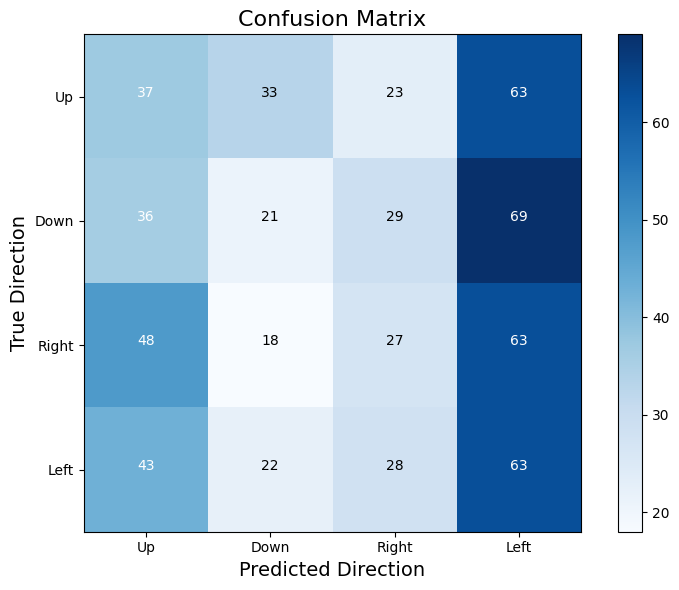


The confusion matrix shows:
- True Up, predicted Up: 37 trials
- True Up, predicted Down: 33 trials
- True Up, predicted Right: 23 trials
- True Up, predicted Left: 63 trials
- True Down, predicted Up: 36 trials
- True Down, predicted Down: 21 trials
- True Down, predicted Right: 29 trials
- True Down, predicted Left: 69 trials
- True Right, predicted Up: 48 trials
- True Right, predicted Down: 18 trials
- True Right, predicted Right: 27 trials
- True Right, predicted Left: 63 trials
- True Left, predicted Up: 43 trials
- True Left, predicted Down: 22 trials
- True Left, predicted Right: 28 trials
- True Left, predicted Left: 63 trials


In [44]:
# Create and display confusion matrix
class_labels = ["Up", "Down", "Right", "Left"]
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix", fontsize=16)
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels)
plt.yticks(tick_marks, class_labels)
plt.xlabel("Predicted Direction", fontsize=14)
plt.ylabel("True Direction", fontsize=14)

# Add text annotations to the confusion matrix
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )

plt.tight_layout()
plt.show()

print("\nThe confusion matrix shows:")
for true_idx, true_label in enumerate(class_labels):
    for pred_idx, pred_label in enumerate(class_labels):
        print(f"- True {true_label}, predicted {pred_label}: {cm[true_idx, pred_idx]} trials")

## SVM Decision Scores

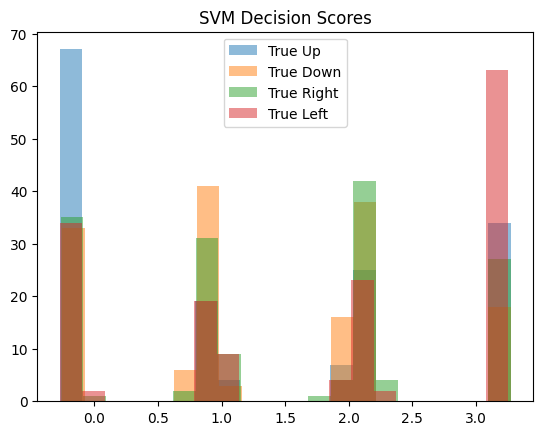

In [45]:
scores = clf.decision_function(X_test_final)

class_labels = ["Up", "Down", "Right", "Left"]
for class_idx, class_label in enumerate(class_labels):
    plt.hist(
        scores[y_test == class_idx, class_idx],
        bins=20,
        alpha=0.5,
        label=f"True {class_label}",
    )
plt.legend()
plt.title("SVM Decision Scores")
plt.show()

## AUC score

In [46]:
from sklearn.metrics import roc_auc_score
probabilities = clf.predict_proba(X_test_final)
print("AUC:", roc_auc_score(y_test, probabilities, multi_class="ovr"))

AUC: 0.4908932175941915


# EEGNET Baseline

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torcheeg.models import EEGNet


In [ ]:
# 1. Filter specifically for Inner Speech trials (Condition label = 1)
# Column 2 holds conditions: 0=Pronounced, 1=Inner Speech, 2=Visualized
inner_speech_mask = (Y[:, 2] == 1)
X_inner = X[inner_speech_mask]
Y_inner = Y[inner_speech_mask][:, 1]  # Column 1 holds the direction labels (0-3)

# 2. Slice the time window (using parameters: 1.5s to 3.5s at 256Hz)
start_sample = int(t_start * fs)
end_sample = int(t_end * fs)
X_inner = X_inner[:, :, start_sample:end_sample]

# 3. Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_inner, Y_inner, test_size=0.20, random_state=23, stratify=Y_inner
)

# 4. Standardize features across time steps
scaler = StandardScaler()
num_channels = X_train.shape[1]
num_time_samples = X_train.shape[2]

# Reshape to 2D to scale, then reshape back
X_train = scaler.fit_transform(X_train.reshape(-1, num_time_samples)).reshape(-1, num_channels, num_time_samples)
X_test = scaler.transform(X_test.reshape(-1, num_time_samples)).reshape(-1, num_channels, num_time_samples)

# 5. Reshape to 4D for EEGNet: (Batch, 1, Channels, Time_Points)
X_train_4d = np.expand_dims(X_train, axis=1)
X_test_4d = np.expand_dims(X_test, axis=1)

# Convert to PyTorch Tensors
train_dataset = TensorDataset(torch.tensor(X_train_4d, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test_4d, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 6. Initialize EEGNet
# Standard setup: Kernel length set to half the sampling rate (256 / 2 = 128)
model = EEGNet(
    chunk_size=num_time_samples,
    num_electrodes=num_channels,
    num_classes=4,
    kernel_num=8,
    dropout=0.5,
    f1=8,
    d=2,
    f2=16
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"EEGNet initialized successfully on device: {device}!")
print(f"Input shape format: (Batch, 1, {num_channels}, {num_time_samples})")


In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 50

print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    
    # Evaluate every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
        
        test_acc = (test_correct / test_total) * 100
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.1f}% | Test Acc: {test_acc:.1f}%")



## References

- Inner Speech Dataset: https://github.com/N-Nieto/Inner_Speech_Dataset

## Citing this work

Please cite this work.
```bibtex
@article{nieto2022thinking,
  title={Thinking out loud, an open-access EEG-based BCI dataset for inner speech recognition},
  author={Nieto, Nicol{\'a}s and Peterson, Victoria and Rufiner, Hugo Leonardo and Kamienkowski, Juan Esteban and Spies, Ruben},
  journal={Scientific Data},
  volume={9},
  number={1},
  pages={1--17},
  year={2022},
  publisher={Nature Publishing Group}
}
```
```bibtex
@article{nieto2021inner,
  title={Inner Speech},
  author={Nieto, N and Peterson, V and Rufiner, HL and Kamienkowski, JE and Spies, R},
  journal={OpenNeuro},
  volume={29},
  pages={227--236},
  year={2021}
}
```